## **2. Carga de datos procesados**

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_parquet("../data/processed/dataset.parquet")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,cellular,5,may,261,1,-1,0,missing,no
1,44,technician,single,secondary,no,29,yes,no,cellular,5,may,151,1,-1,0,missing,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,cellular,5,may,76,1,-1,0,missing,no
3,47,blue-collar,married,secondary,no,1506,yes,no,cellular,5,may,92,1,-1,0,missing,no
4,33,blue-collar,single,secondary,no,1,no,no,cellular,5,may,198,1,-1,0,missing,no


# **2) Split de datos (train/test)**

### Separación de variables predictoras (X) y variable objetivo (y, "has the client subscribed a term deposit?")

In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [4]:
# Separación de variables predictoras (X) y variable objetivo (y, "has the client subscribed a term deposit?")

x_features = df.drop(columns=["y", "duration", "day_of_week", "month"]) 
y_target= df["y"]

# Hacemos el split entre X y Y (80/20)
X_train, X_test, y_train, y_test =train_test_split(
    x_features, 
    y_target, test_size=0.2, 
    random_state=42,
    stratify=y_target
    )    

# Checamos el shape de las variables de entreno y prueba X, Y
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(36168, 13)
(36168,)
(9043, 13)
(9043,)


**Observación**

En `x_features`, decidimos hacer un drop de las siguientes columnas:

1. `y` es nuestra variable target - has the client subscribed a term deposit?.
2. `duration` representa la duración de la última llamada telefónica realizada al cliente. A primera vista parece una variable predictora válida, sin embargo, es una variable trampa: solo se conoce una vez que la llamada ya ocurrió, lo cual se supone no debería de conocerse. Tmabién existe una relación directa con el target, ya que a mayor duración de la llamada, mayor probabilidad de que el cliente se suscriba, lo que introduce data leakage; el objetivo es predecir antes de realizar el contacto si un cliente suscribirá un depósito a plazo, duration es excluida del entrenamiento.
3. para las variables `day_of_week`,`month`, en el EDA encontramos que estas dos variables no generan un impacto relevante en la decisión del client de suscribir un depósito a largo plazo.

## **2.1 Pipeline: preprocesamiento + modelo (evitar data leakage)**

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          45211 non-null  object
 2   marital      45211 non-null  object
 3   education    45211 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      45211 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     45211 non-null  object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

### **Clasificamos cada columna como numérica o categórica**

En nuestro archivo EDA, teníamos lo siguiente:

`X_bin = X[["default","housing","loan"]]` entonces vamos a mirar que tipo de encoder es el mejor approach.

In [8]:
print(f'Variable housing:{df["housing"].value_counts()}\n')
print(f'Variable loan:{df["loan"].value_counts()}\n')
print(f'Variable default:{df["default"].value_counts()}')

Variable housing:housing
yes    25130
no     20081
Name: count, dtype: int64

Variable loan:loan
no     37967
yes     7244
Name: count, dtype: int64

Variable default:default
no     44396
yes      815
Name: count, dtype: int64


In [9]:
numeric_features = ["age", "balance", "campaign", "pdays", "previous"]
categorical_features = ["job", "marital", "education", "contact", "poutcome"]
binary_features= ["default", "housing", "loan"]

### **Pipelines y transformaciones**

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from category_encoders import TargetEncoder



# Hacemos nuestra transformación de variables binarias a numéricas (0 y 1)
for col in binary_features:
    if X_train[col].dtype == "object":  # solo si es texto, así no se hace en 0 cuando ejecutamos el código otra vez
        X_train[col] = X_train[col].map({"yes": 1, "no": 0})
        X_test[col]  = X_test[col].map({"yes": 1, "no": 0})

# Checamos la distrbución para las features binarias
for col in binary_features:
    print(X_train[col].value_counts(), "\n")

default
0    35521
1      647
Name: count, dtype: int64 

housing
1    20182
0    15986
Name: count, dtype: int64 

loan
0    30355
1     5813
Name: count, dtype: int64 



In [11]:
df['poutcome'].value_counts()

poutcome
missing    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [12]:
# Transformers

# ---------------------------Transformadores---------------------------

numeric_transformer_lr = Pipeline(
    steps=[
    ("imputer", SimpleImputer(strategy="median")), # En nuestro EDA vimos que no hay nulos en las variable numéricas, pero por si acaso imputamos con la mediana
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), # si hay un valor en tests que no estaba en train, lo reemplaza por Unknown
        ("encoder", TargetEncoder(smoothing=10)), # mezcla el promedio de categorías con el global
    ]
)
# Usamos TargetEnconder (la profe había usado Dicvectorizer) porque hay variables categóricas con muchas categorías, por ejemplo "job" y "poutcome" solo tiene 4 subcategorías

# ---------------------------Preprocesadores---------------------------

# Combinamos los transformadores usando ColumnTransformer, y dejamos las binarias tal cual (passthrough) porque ya las transformamos arriba

# ---Logistic Regression---
lr_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer_lr, numeric_features),  
    ("cat", categorical_transformer, categorical_features),  
], remainder="passthrough")

# ---Trees que son (RandomForrest Y XGBoost)---
tree_preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),  # No hacemos escalado porque no hace falta en los trees
    ("cat", categorical_transformer, categorical_features),
], remainder="passthrough")  # binary_features pasan directo

# ---------------------------Pipelines (van dentro del mlflow---------------------------

neg_pos_ratio = (y_train == "no").sum() / (y_train == "yes").sum() # para XGBoost, no se puede escalar con class_weight, toca usar scale_pos_weight 

# scale_pos_weight = "It controls the balance of positive and negative weights" y como nuestra base esta desbalanceada, le decimos a XGBoost que le de más peso a la clase chica que es "yes" -> https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

  

## **Entrenar: levantamos el MLflow Tracking Server**

```bash
mlflow server \
  --host 127.0.0.1 \
  --port 5001 \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlruns
```
Opción que me funcionó con Powershell
```powershell
mlflow server `
  --host 127.0.0.1 `
  --port 5001 `
  --backend-store-uri sqlite:///mlflow.db `
  --default-artifact-root ./mlruns
```

`Puerto: http://127.0.0.1:5001`

Y se crea el file `mlflow.db`

In [13]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5001")
print(f"tracking URI: '{mlflow.get_tracking_uri()}'")

tracking URI: 'http://127.0.0.1:5001'


In [14]:
#mlflow.search_experiments()

### **Para LogisticRegression**

1. Vamos a usar principalmente las metricas de roc_auc_score por el desbalance de nuestra variable target y el f1_score

2. Usamos como uno de los parámetros `C` -> 

- C is like your way of telling this machine how much attention to pay to these details. A high C means you're encouraging the machine to take every little detail seriously, aiming for perfection
- a low C is like advising the machine to take a step back and not to obsess over every small detail.

2026/04/10 01:39:36 INFO mlflow.tracking.fluent: Experiment with name 'bank-marketing-tracking' does not exist. Creating a new experiment.


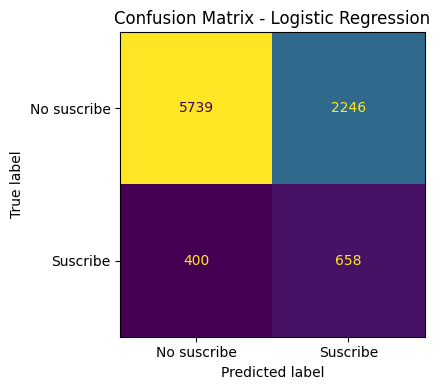

2026/04/10 01:39:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 01:39:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lr_c1.0_iter1000 at: http://127.0.0.1:5001/#/experiments/1/runs/2179dbf5c4184195b571488ec621ad6e
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


In [15]:
from sklearn.metrics import (f1_score, roc_auc_score,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             ConfusionMatrixDisplay
                             )

experiment_name = "bank-marketing-tracking"
mlflow.set_experiment(experiment_name)

class_weight = "balanced"
random_state = 42
C = 1.0
max_iter = 1000

with mlflow.start_run(run_name=f"lr_c{C}_iter{max_iter}"):
    # Tags (metadata)
    mlflow.set_tag("problem_type", "classification")
    mlflow.set_tag("model_family", "logistic_regression")
    mlflow.set_tag("dataset", "bank_marketing")
    mlflow.set_tag("features", ",".join(numeric_features + categorical_features + binary_features))

    # Params
    mlflow.log_param("C", C)
    mlflow.log_param("max_iter", max_iter)
    mlflow.log_param("class_weight", class_weight)
    mlflow.log_param("random_state", random_state)

    # Pipeline
    pipeline_lr = Pipeline(
        steps=[
            ("preprocessor", lr_preprocessor),
            ("model", LogisticRegression(C=C, max_iter=max_iter, class_weight=class_weight, random_state=random_state))
        ]
    )
    # Train + predict
    pipeline_lr.fit(X_train, y_train)
    y_pred_lr = pipeline_lr.predict(X_test)
    y_proba = pipeline_lr.predict_proba(X_test)[:, 1] # para calcular el AUC necesitamos las probabilidades de la clase positiva (yes) y no las predicciones binarias, por eso usamos predict_proba y nos quedamos con la columna 1 que es la de "yes" (la columna 0 es la de "no")

    # Metrics
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_lr))
    mlflow.log_metric("precision", precision_score(y_test, y_pred_lr,pos_label="yes"))
    mlflow.log_metric("recall", recall_score(y_test, y_pred_lr,pos_label="yes"))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred_lr,pos_label="yes"))
    mlflow.log_metric("auc", roc_auc_score(y_test, y_proba))

    # si no uso pos_label="yes" obtengo un error, porque la y no esta encodeada, entonces con pos_label le digo a las metricas que la clase positiva es "yes", así no me da error y me calcula bien las métricas de precision, recall y f1_score para la clase "yes"

    # almacenar nuestras predicciones y probabilidades en mlflow para usarlas después en el dashboard
    preds_path = "predictions_lr.csv" # vamos a guardarlo en este archivo
    pd.DataFrame({
        "y_true_test": y_test, # los valores reales
        "y_pred": y_pred_lr, # lo que nos predijo el modelo
        "y_proba_yes": y_proba  # esta es la probabilidad del AUC de que sea de clase "yes"
    }).to_csv(preds_path, index=False)
    mlflow.log_artifact(preds_path)  # simplemente lo subimos de mlflow

    # No se hace feature_importance para la regresión logística, se hace es coeficientes y este no es tan facíl de implementar acá por el targetencoder

    # Artifact: Confusion Matrix
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_lr,
        display_labels=["No suscribe", "Suscribe"],
        ax=ax, colorbar=False
    )
    ax.set_title("Confusion Matrix - Logistic Regression")
    fig.tight_layout()
    fig.savefig("confusion_matrix_lr.png", dpi=150)
    mlflow.log_artifact("confusion_matrix_lr.png") # Subimos la imagen a mlflow
    plt.show()
    plt.close(fig)

    mlflow.sklearn.log_model(pipeline_lr, artifact_path="model")

**Observación**

1. Para el primer experimento con id 2179dbf5c4184195b571488ec621ad6e, obtuvimos:

-``accuracy:`` 0.7073979873935641
-``precision:`` 0.2265840220385675
-``recall:`` 0.6219281663516069
-``f1_score:`` 0.3321554770318021
-``auc:`` 0.7306444147994882

El modelo presenta un desempeño aceptable en términos de *accuracy*; sin embargo, dado que la variable objetivo está desbalanceada, esta métrica puede resultar engañosa. También muestra una buena capacidad para aprender patrones y clasificar correctamente las clases "Yes" y "No" (*AUC = 0.73*). Además, logra identificar una proporción considerable de clientes que sí se suscriben (*recall ≈ 62%*). No obstante, la *precision* es baja, lo que indica un alto número de falsos positivos (2246 en la matriz de confusión). Esto sugiere que el modelo tiende a sobreestimar la clase positiva, posiblemente debido al uso de `class_weight="balanced"`.



### **Para RandomForestClassifier**

In [16]:
""" random_state=42,
n_estimators=200,
class_weight="balanced", 
max_depth=10,
n_jobs=-1 """




' random_state=42,\nn_estimators=200,\nclass_weight="balanced", \nmax_depth=10,\nn_jobs=-1 '

### **Para XGBClassifier**

In [17]:
""" n_estimators=300, 
eval_metric="auc",
scale_pos_weight=round(neg_pos_ratio, 2),
learning_rate= 0.05 """

' n_estimators=300, \neval_metric="auc",\nscale_pos_weight=round(neg_pos_ratio, 2),\nlearning_rate= 0.05 '